In [1]:
allowedq=Vector{Int64}[]
for ja in 0:2,jb in 0:2
    push!(allowedq,[ja,jb])
end

In [3]:
C3matrix=[-1/2 -√3/2;√3/2 -1/2]

2×2 Matrix{Float64}:
 -0.5       -0.866025
  0.866025  -0.5

In [4]:
C3matrix*C3matrix*C3matrix

2×2 Matrix{Float64}:
 1.0          -1.11022e-16
 1.11022e-16   1.0

In [10]:

include("operators.jl")
using LinearAlgebra
using Plots









flux=4*π
scale=1.0
β=4*flux/(√3*scale^2)


am=4*π/(√3*scale)
mass=0.5;
V0=1000.0
ϕ=π/3;




g1=scale*[1,0]
g2=scale*[1/2,√3/2]
g3=scale*[-1/2,√3/2]
g4=-g1
g5=-g2
g6=-g3
a1m=am*[√3/2,1/2]
a2m=am*[0,1]
Km=(g1+g6)/3
Kp=(g1+g2)/3
γ=[0,0];
mpoint=g1/2



l1=[4,0]
l2=[0,4]
Nx=4;
Ny=4;
Nparticle=8;
L1=l1[1]*a1m+l1[2]*a2m;
L2=l2[1]*a1m+l2[2]*a2m;
area=abs(L1[1]*L2[2]-L2[1]*L1[2]);
Rotminus90=[0 1;-1 0]
T1=2*π/area*Rotminus90*L2
T2=-2*π/area*Rotminus90*L1
g1T=Int.(round.(inv([T1 T2])*g1))
g3T=Int.(round.(inv([T1 T2])*g3))



2-element Vector{Int64}:
 0
 4

In [11]:
Nsec=20
Nq=60

qpath=Matrix{Float64}(undef,2,Nq)
for ja in 1:Nsec
    qpath[:,ja]=γ*(1-ja/Nsec)+mpoint*ja/Nsec
    qpath[:,ja+Nsec]=mpoint*(1-ja/Nsec)+Kp*ja/Nsec
    qpath[:,ja+2*Nsec]=Kp*(1-ja/Nsec)+γ*ja/Nsec
end
qpath


wave=Vector{Int64}[]
cutoff=18
cutoffstandard=7.01*scale
for ja in -cutoff:cutoff, jb in -cutoff:cutoff
    gtest=ja*g1+jb*g3;
    if (gtest[1]^2+gtest[2]^2)<cutoffstandard^2
        push!(wave,ja*g1T+jb*g3T)
    end
end
dimension=length(wave)
println(length(wave))





187


In [12]:
eigenvalue=zeros(dimension,Nq)
for ja in 1:60
  Ham=zeros(ComplexF64,dimension,dimension)
  MoirePo=zeros(ComplexF64,dimension,dimension)

  
  k=qpath[:,ja]
  for jb in 1:length(wave)
  Ham[jb,jb]=norm(k+wave[jb][1]*T1+wave[jb][2]*T2)^2/(2*mass)
  end
  
 for jc in 1:length(wave)
    k1=k+wave[jc][1]*T1+wave[jc][2]*T2
    pos=findfirst(item->item==wave[jc]-g3T,wave)
    if pos≠nothing
   MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-g3,β)
    end
    
  
    pos=findfirst(item->item==wave[jc]-g1T,wave)
    if pos≠nothing
        MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-g1,β)
    end

    pos=findfirst(item->item==wave[jc]+g1T+g3T,wave)
    if pos≠nothing
        MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,g1+g3,β)
    end
 end

 MoirePo=MoirePo+MoirePo'


  eigenvalue[:,ja]=real(eigvals(MoirePo+Ham))

end


In [1]:
sum([1 2;3 4])

10

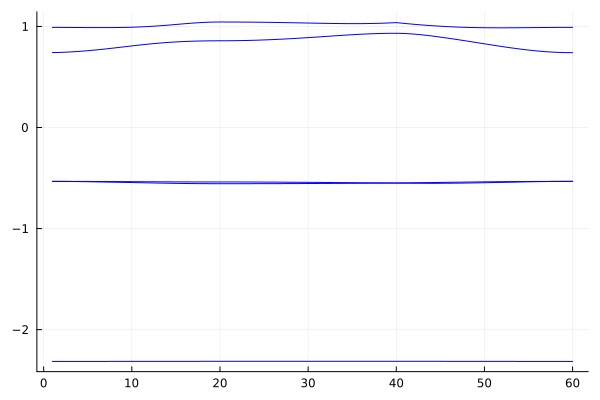

In [13]:
myplot=plot()

plot!(1:Nq,eigenvalue[1:5,:]',legend=false,color="blue")


display(myplot)

We calculate the berry curvature distribution using Fukui method below

In [14]:
function metric(wavelist::Vector{Vector{Int64}},β::Float64,k::Vector{Float64},q::Vector{Float64},T1::Vector{Float64},T2::Vector{Float64})::Matrix{ComplexF64}
  Amatrix=zeros(ComplexF64,length(wavelist),length(wavelist))
  for ja in 1:length(wavelist)
  Amatrix[ja,ja]=overlap(k+wavelist[ja][1]*T1+wavelist[ja][2]*T2,q,β)
  end
  return Amatrix
end

metric (generic function with 1 method)

In [15]:
N4=35;
eigenvector_bc=zeros(ComplexF64,dimension,N4+1,N4+1)
for jx in 1:N4+1, jy in 1:N4+1
    k=jx/N4*g1+jy/N4*g3
    Ham=zeros(ComplexF64,dimension,dimension)
    MoirePo=zeros(ComplexF64,dimension,dimension)
    for jb in 1:length(wave)
        Ham[jb,jb]=norm(k+wave[jb][1]*T1+wave[jb][2]*T2)^2/(2*mass)
    end

    for jc in 1:length(wave)
        k1=k+wave[jc][1]*T1+wave[jc][2]*T2
        pos=findfirst(item->item==wave[jc]-g3T,wave)
        if pos≠nothing
       MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-g3,β)
        end
        
      
        pos=findfirst(item->item==wave[jc]-g1T,wave)
        if pos≠nothing
            MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,-g1,β)
        end
    
        pos=findfirst(item->item==wave[jc]+g1T+g3T,wave)
        if pos≠nothing
            MoirePo[jc,pos]=V0*exp(im*ϕ)*overlap(k1,g1+g3,β)
        end
     end
    
     MoirePo=MoirePo+MoirePo'
     
    eigenvector_bc[:,jx,jy]=eigvecs(Ham+MoirePo)[:,1] 


end

Uonelink=zeros(ComplexF64,N4,N4+1)
Utwolink=zeros(ComplexF64,N4+1,N4)

for ja in 1:N4, jb in 1:N4+1
    Amatrix=metric(wave,β,ja/N4*g1+jb/N4*g3,1/N4*g1,T1,T2)
 Uonelink[ja,jb]=dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja+1,jb])/abs(dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja+1,jb]))
end

for ja in 1:N4+1, jb in 1:N4
    Amatrix=metric(wave,β,ja/N4*g1+jb/N4*g3,1/N4*g3,T1,T2)
 Utwolink[ja,jb]=dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja,jb+1])/abs(dot(eigenvector_bc[:,ja,jb],Amatrix*eigenvector_bc[:,ja,jb+1]))
end

Flink=zeros(ComplexF64,N4,N4)
for ja in 1:N4, jb in 1:N4
 Flink[ja,jb]=log(Uonelink[ja,jb]*Utwolink[ja+1,jb]/(Uonelink[ja,jb+1]*Utwolink[ja,jb]))
end
chern=sum(Flink)/(2*π*im)

3.9999999999936957 + 3.6672492604063074e-17im

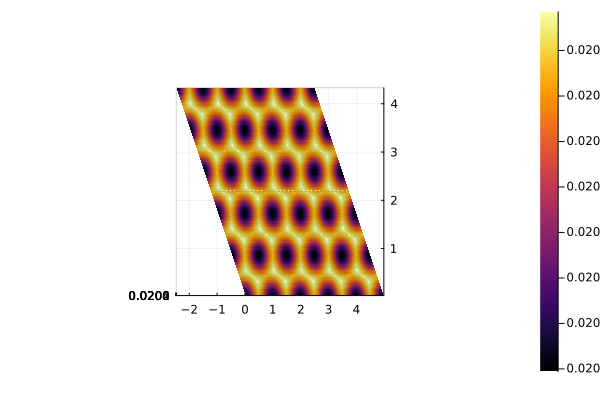

In [16]:
xgrid=zeros(Float64,5*N4,5*N4)
ygrid=zeros(Float64,5*N4,5*N4)
Fgrid=zeros(Float64,5*N4,5*N4)
for ja in 1:5*N4, jb in 1:5*N4
 
    xgrid[ja,jb]=(ja/N4*g1+jb/N4*g3)[1]
    ygrid[ja,jb]=(ja/N4*g1+jb/N4*g3)[2]
    Fgrid[ja,jb]=imag(Flink[mod(ja-1,N4)+1,mod(jb-1,N4)+1])
end
plot(xgrid,ygrid,Fgrid,st=:surf,camera=(0,90))